<a href="https://colab.research.google.com/github/vencov/FAV_upsidedown/blob/main/TutOEME/EX_chirp_time_averaging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time-domain averaging of chirp-evoked ear-canal responses

When a chirp stimulus is repeated many times and the ear-canal recording
is cut into one epoch per chirp, the **stimulus-evoked response** is the
same (phase-locked) in every epoch, while the **noise** (physiological,
electronic) is essentially independent from repeat to repeat. Averaging
the epochs together cancels the noise (its amplitude shrinks roughly as
1/√N) while leaving the evoked response untouched — this is the standard
trick used to pull small otoacoustic/ear-canal responses out of a noisy
recording.

This notebook:
1. loads a recording consisting of `Nchirps` repeated chirps back to back,
2. cuts it into individual chirp-length epochs,
3. plots several raw (single-trial) epochs so you can see how noisy any
   *one* chirp response looks,
4. averages across epochs and overlays the averaged response on a single
   raw epoch, so you can see directly how much the noise is reduced.


## 1. Setup

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import urllib.request

plt.rcParams['figure.dpi'] = 100


## 2. Load the data

Set `USE_DEMO_DATA = True` to try the notebook with a synthetic
(simulated) recording — useful for testing the notebook itself before
you have real data, or for a first pass through the exercise.

Set `USE_DEMO_DATA = False` to use your own recording. Your `.mat` file
should contain the same fields as in the lab recordings:
- `y1all`, `y2all` — the two recorded ear-canal channels (one long
  vector each, containing all `Nchirps` repeats back to back)
- `Nsamp` — number of samples per chirp
- `fsamp` — sampling rate (Hz)
- `latSC` — sound-card / system latency to strip from the start (samples)

`Nchirps` (how many chirps were recorded) is **not** stored in the file —
set it below to match your recording protocol.


In [20]:
USE_DEMO_DATA = False  # <-- set to False to load your own .mat file

if USE_DEMO_DATA:
    # ---- synthetic demo recording: a short chirp buried in noise, repeated Nchirps times ----
    from scipy.signal import chirp as make_chirp

    fsamp = 48000.0
    Nsamp = 2000
    latSC = 50
    Nchirps = 300

    rng = np.random.default_rng(0)
    t_chirp = np.arange(Nsamp) / fsamp
    true_response = 0.05 * make_chirp(t_chirp, f0=500, f1=8000, t1=t_chirp[-1], method='linear')

    noise_amp = 0.5
    y1all = np.concatenate([
        np.zeros(latSC),
        np.tile(true_response, Nchirps) + noise_amp * rng.standard_normal(Nchirps * Nsamp)
    ])
    y2all = np.concatenate([
        np.zeros(latSC),
        np.tile(true_response, Nchirps) + noise_amp * rng.standard_normal(Nchirps * Nsamp)
    ])
    print(f"Using synthetic demo data: Nchirps={Nchirps}, Nsamp={Nsamp}, fsamp={fsamp} Hz")

else:
    fname = 'InEarData_tubePok.mat'  # <-- change to your file name

    base_url = "https://raw.githubusercontent.com/vencov/FAV_upsidedown/main/TutOEME/"

    if os.path.exists(fname): # forced to load latest file on github
        os.remove(fname)

    if not os.path.exists(fname):
        urllib.request.urlretrieve(base_url + fname, fname)

    data = loadmat(fname)
    y1all = data['y1all'][0] # response of the first speaker (chirp train)
    y2all = data['y2all'][0] # response of the second speaker (chirp train)
    fsamp = float(data['fsamp'][0][0]) # sampling frequency
    Nsamp = int(data['buffersize'][0][0])  # number of samples i each chirp
    Nchirps = int(data['Nchirps'][0][0])   # number of chirps in the reaponse
    AmpChirp = int(data['AmpChirp'][0][0]) # amplitude of the chirp
    latSC = int(data['lat_SC'][0][0])  # latency of the sound card


    print(f"Loaded '{fname}': Nchirps={Nchirps}, Nsamp={Nsamp}, fsamp={fsamp} Hz")


Loaded 'InEarData_tubePok.mat': Nchirps=300, Nsamp=2048, fsamp=44100.0 Hz


## 3. Cut the recording into individual chirp epochs

Strip the sound-card latency from the start, then reshape the long
recording into an array of shape `(Nchirps, Nsamp)` — one row per chirp
repeat.


In [21]:
def epoch_chirps(y, latSC, Nsamp, Nchirps):
    '''Strip the initial latency and cut y into Nchirps epochs of Nsamp samples each.'''
    y_stripped = y[latSC:]
    return np.reshape(y_stripped[:Nchirps * Nsamp], (Nchirps, Nsamp))


y1_epochs = epoch_chirps(y1all, latSC, Nsamp, Nchirps)  # shape (Nchirps, Nsamp)
y2_epochs = epoch_chirps(y2all, latSC, Nsamp, Nchirps)

t_ms = np.arange(Nsamp) / fsamp * 1000  # time axis for one epoch, in ms

print(f"y1_epochs shape: {y1_epochs.shape}   (Nchirps x Nsamp)")


y1_epochs shape: (300, 2048)   (Nchirps x Nsamp)


## 4. A few individual (single-trial) chirp responses

Before averaging, look at several individual chirps on their own — this
is what the raw, unaveraged response actually looks like.


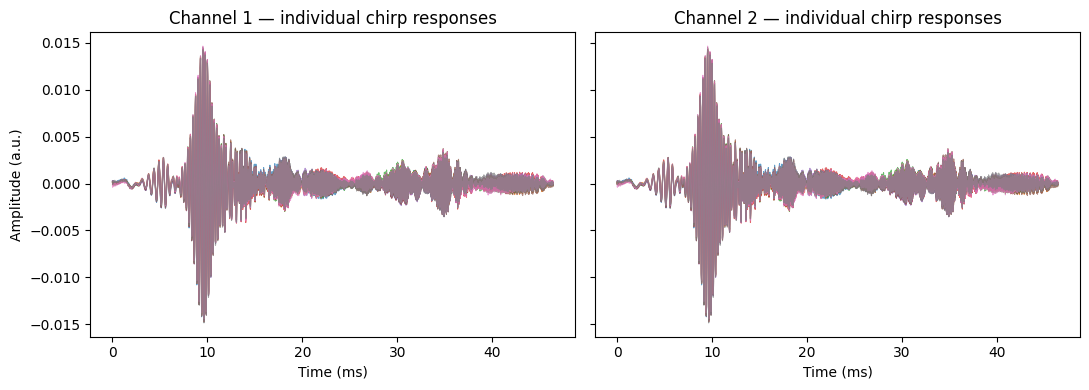

In [22]:
chirps_to_show = np.arange(10, 18)  # 8 example chirps

fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for idx in chirps_to_show:
    axs[0].plot(t_ms, y1_epochs[idx], alpha=0.7, linewidth=0.8)
    axs[1].plot(t_ms, y2_epochs[idx], alpha=0.7, linewidth=0.8)

axs[0].set_title('Channel 1 — individual chirp responses')
axs[1].set_title('Channel 2 — individual chirp responses')
for ax in axs:
    ax.set_xlabel('Time (ms)')
axs[0].set_ylabel('Amplitude (a.u.)')
plt.tight_layout()
plt.show()


## 5. Average across chirps, and compare to a single raw chirp

The first few chirps are skipped (`Nchskip`) to avoid any onset
transient/adaptation at the very start of the stimulus train. The rest
are averaged together and overlaid on one single (unaveraged) chirp
response, so the noise reduction from averaging is directly visible.


Frames to skip: []
Frames to skip: []


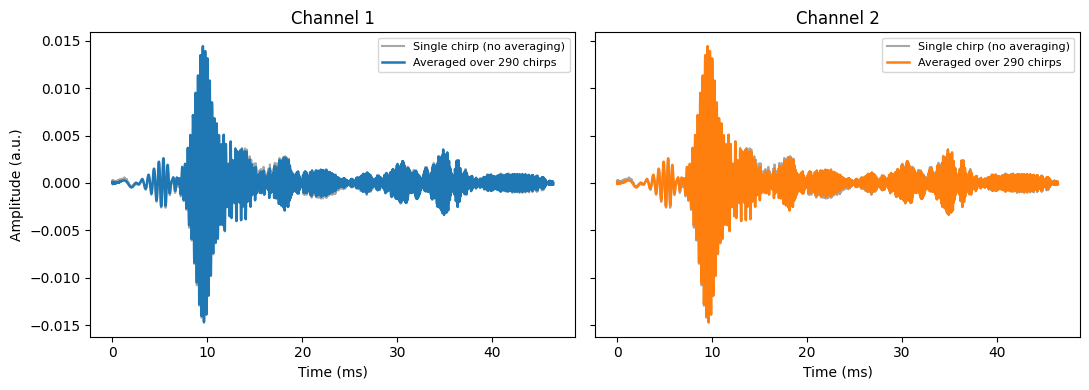

In [25]:
Nchskip = 10  # skip the first few chirps (onset transient), same as in the lab script

y_mean1 = np.mean(y1_epochs[Nchskip:],axis=0)
y_mean2 = np.mean(y2_epochs[Nchskip:],axis=0)

# artifact rejection (reject frams which are affected by some artifact)

y_dev1 = y1_epochs[Nchskip:] - y_mean1
y_dev2 = y2_epochs[Nchskip:] - y_mean2
# Example threshold
threshold = 0.01  # Adjust this based on your criteria

# Compute the maximum absolute deviation for each frame
max_dev_per_frame1 = np.max(np.abs(y_dev1), axis=0)
max_dev_per_frame2 = np.max(np.abs(y_dev2), axis=0)

# Identify frames where the deviation exceeds the threshold
frames_to_skip1 = np.where(max_dev_per_frame1 > threshold)[0]
frames_to_skip2 = np.where(max_dev_per_frame2 > threshold)[0]

print("Frames to skip:", frames_to_skip1)
print("Frames to skip:", frames_to_skip2)

# Select only the columns that are NOT in frames_to_skip
valid_columns1 = np.setdiff1d(np.arange(y1_epochs[Nchskip:].shape[0]), frames_to_skip1)
valid_columns2 = np.setdiff1d(np.arange(y2_epochs[Nchskip:].shape[0]), frames_to_skip2)
# Compute the mean only for the selected columns
y_avg1 = np.mean(y1_epochs[Nchskip:][:, valid_columns1], axis=1)
y_avg2 = np.mean(y2_epochs[Nchskip:][:, valid_columns2], axis=1)


single_idx = Nchskip  # the first chirp actually used in the average, for a fair comparison

fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axs[0].plot(t_ms, y1_epochs[single_idx], color='gray', alpha=0.7,
            label='Single chirp (no averaging)')
axs[0].plot(t_ms, y1_avg, color='C0', linewidth=1.8,
            label=f'Averaged over {Nchirps - Nchskip} chirps')
axs[0].set_title('Channel 1')

axs[1].plot(t_ms, y2_epochs[single_idx], color='gray', alpha=0.7,
            label='Single chirp (no averaging)')
axs[1].plot(t_ms, y2_avg, color='C1', linewidth=1.8,
            label=f'Averaged over {Nchirps - Nchskip} chirps')
axs[1].set_title('Channel 2')

for ax in axs:
    ax.set_xlabel('Time (ms)')
    ax.legend(loc='upper right', fontsize=8)
axs[0].set_ylabel('Amplitude (a.u.)')
plt.tight_layout()
plt.show()


In [ ]:


def makeChirp(f1,f2,Nsamp,fsamp):
    '''
    generate a short chirp (linearly swept sine)
    '''
    T = Nsamp/fsamp  # duration of the chirp

    tx = np.arange(0,Nsamp/fsamp,1/fsamp)  # time axis

    A = 1
    T = Nsamp/fsamp

    y = np.zeros_like(tx)
    for k in range(len(tx)):
        y[k] = A*np.sin(2*np.pi*(f1+(f2-f1)/(2*(T))*tx[k])*tx[k])

    return y


def makeChirpTrain(f1,f2,Nsamp,fsamp,Nchirps):
    '''
    generate a train of chirps (linearly swept sines)
    '''

    chirp = makeChirp(f1,f2,Nsamp,fsamp) # make one chirp
    chirptrain = np.tile(chirp,(Nchirps,))  # repeate the chirp Nchirp times

    return chirptrain, chirp

# we get the chirp in time domain which was used for measurement
f1 = 0  # start frequency
f2 = fsamp/2 # stop frequency
chirptrain, chirpIn = makeChirpTrain(f1,f2,Nsamp,fsamp,Nchirps)
# calculate spectrum

Nmean1 = len(y_mean1)  # length of the data
NmeanUp1 = int(2**np.ceil(2+np.log2(Nmean1)))  # interpolated length of the spectrum
ChResp1 =  np.fft.rfft(y_mean1,NmeanUp1)/np.fft.rfft(AmpChirp*chirpIn,NmeanUp1)
fxCh1 = np.arange(NmeanUp1)*fsamp/NmeanUp1
fxCh1 = fxCh1[:NmeanUp1//2+1]

Nmean2 = len(y_mean2)  # length of the data
NmeanUp2 = int(2**np.ceil(2+np.log2(Nmean2)))  # interpolated length of the spectrum
ChResp2 =  np.fft.rfft(y_mean2,NmeanUp2)/np.fft.rfft(AmpChirp*chirpIn,NmeanUp2)
fxCh2 = np.arange(NmeanUp2)*fsamp/NmeanUp2
fxCh2 = fxCh2[:NmeanUp2//2+1]

# to smooth out noise, Savitzky-Golay filter is used
ChRespAbs1 = savgol_filter(np.abs(ChResp1), 20, 2)
ChRespImag1 = savgol_filter(np.unwrap(np.angle(ChResp1)), 20, 2)

ChRespAbs2 = savgol_filter(np.abs(ChResp2), 20, 2)
ChRespImag2 = savgol_filter(np.unwrap(np.angle(ChResp2)), 20, 2)

# change on 8.3.2024 to remove miccal
#MicC = loadmat('MicCalCurve.mat')  # load calibration curve for the microphone
#fx = MicC['fx'][0]
#Hoaemic = MicC['Hoaemic'][0]
fx = np.arange(100,18e3,5)

ChRespI1 = np.interp(fx,fxCh1,ChRespAbs1)*np.exp(1j*np.interp(fx,fxCh1,ChRespImag1))
ChRespI2 = np.interp(fx,fxCh2,ChRespAbs2)*np.exp(1j*np.interp(fx,fxCh2,ChRespImag2))

#Hinear1 = ChRespI1/(Hoaemic*(10**(MicGain/20))) # convert recorded response to Pascals
#Hinear2 = ChRespI2/(Hoaemic*(10**(MicGain/20)))
Hinear1 = ChRespI1/(0.003*10**(MicGain/20))
Hinear2 = ChRespI2/(0.003*10**(MicGain/20))

